# Домашнее задание №1. Сравнение алгоритмов бустинга

**Задача:** сравнить четыре реализации градиентного бустинга на бинарной классификации:

1. `sklearn.ensemble.GradientBoostingClassifier`;
2. `xgboost.XGBClassifier`;
3. `catboost.CatBoostClassifier`;
4. `lightgbm.LGBMClassifier`.

Используется датасет **Telco Customer Churn** (`blastchar/telco-customer-churn`), целевая переменная — `Churn`.

Основная метрика — **ROC-AUC**, поскольку классы несбалансированы. Accuracy приводится как дополнительная метрика. Сначала сравниваются модели с параметрами по умолчанию, затем для каждой модели проводится подбор гиперпараметров на стратифицированной кросс-валидации.

## 1. Импорт библиотек и загрузка данных

Для воспроизведения необходимы пакеты `kagglehub`, `xgboost`, `catboost` и `lightgbm`. 

In [14]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from IPython.display import Markdown, display
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    accuracy_score,
    classification_report,
    roc_auc_score,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
pd.set_option("display.max_colwidth", 120)
sns.set_theme(style="whitegrid")

In [15]:
dataset_dir = Path(kagglehub.dataset_download("blastchar/telco-customer-churn"))
csv_files = sorted(dataset_dir.glob("*.csv"))
if not csv_files:
    raise FileNotFoundError(f"CSV-файл не найден в {dataset_dir}")

df = pd.read_csv(csv_files[0])
target_col = "Churn"

print(f"Размер датасета: {df.shape[0]} строк, {df.shape[1]} столбец")
display(df.head())

Размер датасета: 7043 строк, 21 столбец


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 2. EDA

Проверим типы, пропуски, дубликаты, баланс классов и связи целевой переменной с числовыми и категориальными признаками. Пустые строки в `TotalCharges` отдельно преобразуются в `NaN`, поскольку при чтении CSV они не распознаются как пропуски.

In [16]:
eda_df = df.copy()
eda_df["TotalCharges"] = pd.to_numeric(eda_df["TotalCharges"], errors="coerce")

quality_report = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "unique": df.nunique(dropna=False),
    "missing_after_type_fix": eda_df.isna().sum(),
})

print(f"Полных дубликатов: {df.duplicated().sum()}")
print(f"Пропусков в TotalCharges после преобразования: {eda_df['TotalCharges'].isna().sum()}")
display(quality_report)
display(eda_df[["SeniorCitizen", "tenure", "MonthlyCharges", "TotalCharges"]].describe().T)

class_distribution = (
    df[target_col]
    .value_counts()
    .rename_axis("Churn")
    .to_frame("count")
    .assign(share=lambda x: x["count"] / x["count"].sum())
)
display(class_distribution)

Полных дубликатов: 0
Пропусков в TotalCharges после преобразования: 11


,dtype,unique,missing_after_type_fix
customerID,object,7043,0
gender,object,2,0
SeniorCitizen,int64,2,0
Partner,object,2,0
Dependents,object,2,0
tenure,int64,73,0
PhoneService,object,2,0
MultipleLines,object,3,0
InternetService,object,3,0
OnlineSecurity,object,3,0


,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.00,0.000,0.0000,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.00,29.000,55.0000,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.50,70.350,89.8500,118.75
TotalCharges,7032.0,2283.300441,2266.771362,18.80,401.45,1397.475,3794.7375,8684.80


,count,share
Churn,,
No,5174,0.73463
Yes,1869,0.26537


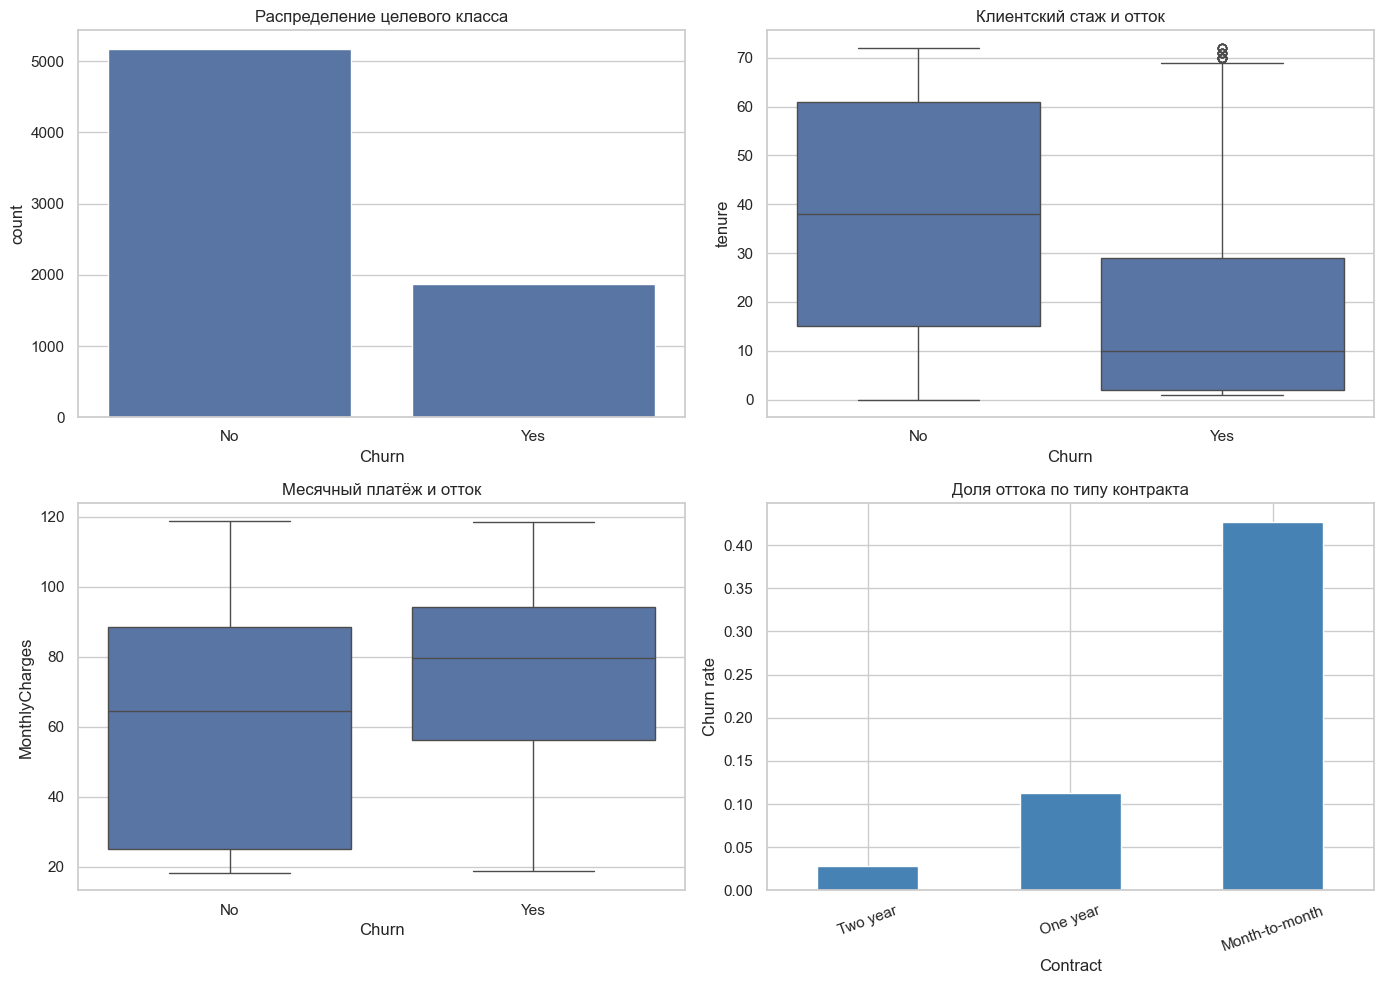

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.countplot(data=df, x=target_col, ax=axes[0, 0])
axes[0, 0].set_title("Распределение целевого класса")

sns.boxplot(data=eda_df, x=target_col, y="tenure", ax=axes[0, 1])
axes[0, 1].set_title("Клиентский стаж и отток")

sns.boxplot(data=eda_df, x=target_col, y="MonthlyCharges", ax=axes[1, 0])
axes[1, 0].set_title("Месячный платёж и отток")

contract_rate = pd.crosstab(df["Contract"], df[target_col], normalize="index")["Yes"].sort_values()
contract_rate.plot(kind="bar", ax=axes[1, 1], color="steelblue")
axes[1, 1].set_title("Доля оттока по типу контракта")
axes[1, 1].set_ylabel("Churn rate")
axes[1, 1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

Средние значения числовых признаков по классам:


,tenure,MonthlyCharges,TotalCharges
Churn,,,
No,37.57,61.27,2555.34
Yes,17.98,74.44,1531.80


Категории с максимальной долей оттока:


,feature,highest_risk_category,churn_rate,clients
14,PaymentMethod,Electronic check,45.29%,2365
12,Contract,Month-to-month,42.71%,3875
5,InternetService,Fiber optic,41.89%,3096
6,OnlineSecurity,No,41.77%,3498
9,TechSupport,No,41.64%,3473
7,OnlineBackup,No,39.93%,3088
8,DeviceProtection,No,39.13%,3095
11,StreamingMovies,No,33.68%,2785
13,PaperlessBilling,Yes,33.57%,4171
10,StreamingTV,No,33.52%,2810


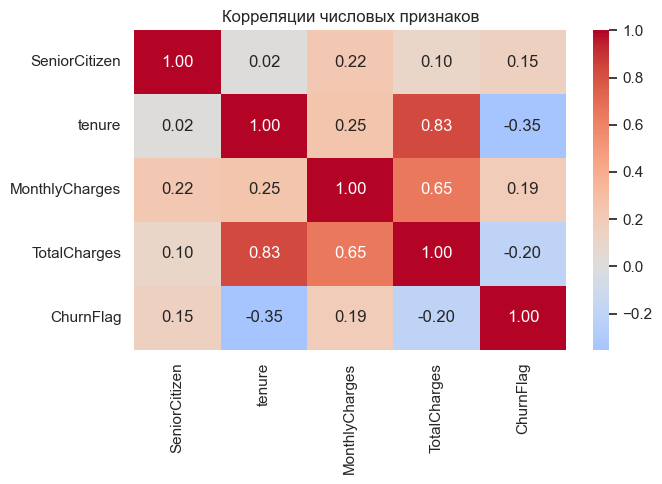

In [18]:
eda_df["ChurnFlag"] = eda_df[target_col].map({"No": 0, "Yes": 1})

print("Средние значения числовых признаков по классам:")
display(eda_df.groupby(target_col)[["tenure", "MonthlyCharges", "TotalCharges"]].mean().round(2))

cat_cols = [
    col for col in eda_df.select_dtypes(include=["object", "category"]).columns
    if col not in [target_col, "customerID"]
]
cat_churn_rows = []
for col in cat_cols:
    rates = eda_df.groupby(col, dropna=False)["ChurnFlag"].agg(["mean", "count"]).reset_index()
    rates = rates[rates["count"] >= 50]
    if not rates.empty:
        row = rates.sort_values("mean", ascending=False).iloc[0]
        cat_churn_rows.append({
            "feature": col,
            "highest_risk_category": row[col],
            "churn_rate": row["mean"],
            "clients": int(row["count"]),
        })

category_risk = pd.DataFrame(cat_churn_rows).sort_values("churn_rate", ascending=False)
print("Категории с максимальной долей оттока:")
display(category_risk.head(10).style.format({"churn_rate": "{:.2%}"}))

numeric_corr = eda_df.corr(numeric_only=True)
plt.figure(figsize=(7, 5))
sns.heatmap(numeric_corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Корреляции числовых признаков")
plt.tight_layout()
plt.show()

### Выводы по EDA

- Датасет содержит 7043 клиента и 21 исходный столбец; целевая переменная `Churn` бинарная.
- Доля клиентов с оттоком составляет около 26.5%, поэтому одной accuracy недостаточно; основной метрикой выбрана ROC-AUC.
- В `TotalCharges` есть пустые строки, которые после преобразования дают 11 пропусков.
- Клиенты с небольшим `tenure`, помесячным контрактом, оплатой electronic check и отсутствием дополнительных сервисов уходят чаще.
- У ушедших клиентов в среднем выше `MonthlyCharges` и заметно меньше `tenure`.

## 3. Preprocessing и feature engineering

Сначала данные делятся на train/test. Все обучаемые преобразования затем помещаются в sklearn `Pipeline`, поэтому медиана и `LabelEncoder` на каждой итерации кросс-валидации обучаются только на соответствующей обучающей части. Это исключает утечку информации из test и validation.

Преобразования:

- `customerID` удаляется как технический идентификатор;
- `TotalCharges` переводится в число, пропуски заполняются медианой train;
- категориальные признаки кодируются отдельным `LabelEncoder`; неизвестным категориям назначается `-1`;
- добавляются `avg_charge_per_tenure`, `is_new_customer` и количество подключённых онлайн-сервисов.

In [19]:
class TelcoPreprocessor(BaseEstimator, TransformerMixin):
    "Preprocessing Telco Churn без использования информации из holdout."

    service_columns = [
        "OnlineSecurity",
        "OnlineBackup",
        "DeviceProtection",
        "TechSupport",
        "StreamingTV",
        "StreamingMovies",
    ]

    def _prepare_base(self, X):
        data = X.copy()
        data["TotalCharges"] = pd.to_numeric(data["TotalCharges"], errors="coerce")
        if hasattr(self, "total_charges_median_"):
            data["TotalCharges"] = data["TotalCharges"].fillna(self.total_charges_median_)

        data = data.drop(columns=["customerID"], errors="ignore")
        data["avg_charge_per_tenure"] = data["TotalCharges"] / (data["tenure"] + 1)
        data["is_new_customer"] = (data["tenure"] <= 3).astype(int)

        available_services = [col for col in self.service_columns if col in data.columns]
        data["num_online_services"] = (data[available_services] == "Yes").sum(axis=1)
        return data

    def fit(self, X, y=None):
        total_charges = pd.to_numeric(X["TotalCharges"], errors="coerce")
        self.total_charges_median_ = float(total_charges.median())
        data = self._prepare_base(X)

        self.feature_names_in_ = list(data.columns)
        self.categorical_columns_ = list(data.select_dtypes(include=["object", "category"]).columns)
        self.label_encoders_ = {}

        for col in self.categorical_columns_:
            encoder = LabelEncoder()
            encoder.fit(data[col].fillna("__MISSING__").astype(str))
            self.label_encoders_[col] = encoder
        return self

    def transform(self, X):
        data = self._prepare_base(X)
        data = data.reindex(columns=self.feature_names_in_)

        for col, encoder in self.label_encoders_.items():
            mapping = {label: idx for idx, label in enumerate(encoder.classes_)}
            values = data[col].fillna("__MISSING__").astype(str)
            data[col] = values.map(mapping).fillna(-1).astype(int)

        return data.astype(float)


X_raw = df.drop(columns=[target_col])
y = df[target_col].map({"No": 0, "Yes": 1})

X_train, X_test, y_train, y_test = train_test_split(
    X_raw,
    y,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y,
)

print(f"Train: {X_train.shape}; test: {X_test.shape}")
print(f"Доля Churn в train: {y_train.mean():.2%}; в test: {y_test.mean():.2%}")

Train: (5282, 20); test: (1761, 20)
Доля Churn в train: 26.54%; в test: 26.52%


## 4. Четыре модели «из коробки»

Для честного baseline используются параметры моделей по умолчанию.

In [20]:
def make_pipeline(model):
    return Pipeline([
        ("preprocess", TelcoPreprocessor()),
        ("model", model),
    ])


baseline_estimators = {
    "sklearn GradientBoosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
    "XGBoost": XGBClassifier(random_state=RANDOM_STATE, n_jobs=1),
    "CatBoost": CatBoostClassifier(
        random_state=RANDOM_STATE,
        verbose=False,
        allow_writing_files=False,
        thread_count=1,
    ),
    "LightGBM": LGBMClassifier(random_state=RANDOM_STATE, verbosity=-1, n_jobs=1),
}

baseline_rows = []
baseline_models = {}

for name, estimator in baseline_estimators.items():
    print(f"Обучение baseline: {name}")
    pipeline = make_pipeline(clone(estimator))
    pipeline.fit(X_train, y_train)
    probabilities = pipeline.predict_proba(X_test)[:, 1]
    predictions = (probabilities >= 0.5).astype(int)

    baseline_rows.append({
        "model": name,
        "test_roc_auc": roc_auc_score(y_test, probabilities),
        "test_accuracy": accuracy_score(y_test, predictions),
    })
    baseline_models[name] = pipeline

baseline_results = (
    pd.DataFrame(baseline_rows)
    .sort_values("test_roc_auc", ascending=False)
    .reset_index(drop=True)
)
display(baseline_results.style.format({"test_roc_auc": "{:.4f}", "test_accuracy": "{:.4f}"}))

baseline_winner = baseline_results.iloc[0]
display(Markdown(
    f"**Ответ:** до настройки лидирует **{baseline_winner['model']}** "
    f"с ROC-AUC **{baseline_winner['test_roc_auc']:.4f}** "
    f"и accuracy **{baseline_winner['test_accuracy']:.4f}**."
))

Обучение baseline: sklearn GradientBoosting
Обучение baseline: XGBoost
Обучение baseline: CatBoost
Обучение baseline: LightGBM


,model,test_roc_auc,test_accuracy
0,sklearn GradientBoosting,0.8451,0.7995
1,CatBoost,0.8381,0.7978
2,LightGBM,0.8353,0.7933
3,XGBoost,0.8183,0.7757


**Ответ:** до настройки лидирует **sklearn GradientBoosting** с ROC-AUC **0.8451** и accuracy **0.7995**.

Обучение baseline: LightGBM


,model,test_roc_auc,test_accuracy
0,sklearn GradientBoosting,0.8451,0.7995
1,CatBoost,0.8381,0.7978
2,LightGBM,0.8353,0.7933
3,XGBoost,0.8183,0.7757


**Ответ:** до настройки лидирует **sklearn GradientBoosting** с ROC-AUC **0.8451** и accuracy **0.7995**.

## 5. Настройка гиперпараметров на кросс-валидации

Для каждой из четырёх моделей проверяется компактная сетка основных гиперпараметров. Подбор выполняется только на `X_train` с помощью стратифицированной 3-fold CV и метрики ROC-AUC. Благодаря `Pipeline` preprocessing заново обучается внутри каждого fold. Тестовая выборка в выборе гиперпараметров не участвует.

In [21]:
param_grids = {
    "sklearn GradientBoosting": {
        "model__n_estimators": [100, 200],
        "model__learning_rate": [0.03, 0.10],
        "model__max_depth": [2, 3],
        "model__subsample": [0.8],
    },
    "XGBoost": {
        "model__n_estimators": [100, 250],
        "model__learning_rate": [0.03, 0.10],
        "model__max_depth": [3, 5],
        "model__subsample": [0.8],
        "model__colsample_bytree": [0.8],
    },
    "CatBoost": {
        "model__iterations": [200, 500],
        "model__learning_rate": [0.03, 0.10],
        "model__depth": [4, 6],
        "model__l2_leaf_reg": [3],
    },
    "LightGBM": {
        "model__n_estimators": [100, 250],
        "model__learning_rate": [0.03, 0.10],
        "model__num_leaves": [15, 31],
        "model__subsample": [0.8],
        "model__subsample_freq": [1],
        "model__colsample_bytree": [0.8],
    },
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
tuned_rows = []
tuned_models = {}
search_objects = {}

for name, estimator in baseline_estimators.items():
    combinations = int(np.prod([len(values) for values in param_grids[name].values()]))
    print(f"Подбор {name}: {combinations} комбинаций × {cv.get_n_splits()} fold")

    search = GridSearchCV(
        estimator=make_pipeline(clone(estimator)),
        param_grid=param_grids[name],
        scoring="roc_auc",
        cv=cv,
        n_jobs=-1,
        refit=True,
        return_train_score=False,
    )
    search.fit(X_train, y_train)

    probabilities = search.predict_proba(X_test)[:, 1]
    predictions = (probabilities >= 0.5).astype(int)
    tuned_rows.append({
        "model": name,
        "best_cv_roc_auc": search.best_score_,
        "test_roc_auc": roc_auc_score(y_test, probabilities),
        "test_accuracy": accuracy_score(y_test, predictions),
        "best_params": search.best_params_,
    })
    tuned_models[name] = search.best_estimator_
    search_objects[name] = search

tuned_results = (
    pd.DataFrame(tuned_rows)
    .sort_values("test_roc_auc", ascending=False)
    .reset_index(drop=True)
)
display(tuned_results.style.format({
    "best_cv_roc_auc": "{:.4f}",
    "test_roc_auc": "{:.4f}",
    "test_accuracy": "{:.4f}",
}))

Подбор sklearn GradientBoosting: 8 комбинаций × 3 fold
Подбор XGBoost: 8 комбинаций × 3 fold
Подбор CatBoost: 8 комбинаций × 3 fold
Подбор LightGBM: 8 комбинаций × 3 fold


,model,best_cv_roc_auc,test_roc_auc,test_accuracy,best_params
0,LightGBM,0.8453,0.8485,0.7978,"{'model__colsample_bytree': 0.8, 'model__learning_rate': 0.03, 'model__n_estimators': 100, 'model__num_leaves': 15, 'model__subsample': 0.8, 'model__subsample_freq': 1}"
1,CatBoost,0.8466,0.8479,0.7995,"{'model__depth': 4, 'model__iterations': 200, 'model__l2_leaf_reg': 3, 'model__learning_rate': 0.03}"
2,XGBoost,0.8453,0.8476,0.8024,"{'model__colsample_bytree': 0.8, 'model__learning_rate': 0.03, 'model__max_depth': 3, 'model__n_estimators': 250, 'model__subsample': 0.8}"
3,sklearn GradientBoosting,0.8464,0.8441,0.7961,"{'model__learning_rate': 0.1, 'model__max_depth': 2, 'model__n_estimators': 100, 'model__subsample': 0.8}"


Подбор CatBoost: 8 комбинаций × 3 fold


Подбор LightGBM: 8 комбинаций × 3 fold


,model,best_cv_roc_auc,test_roc_auc,test_accuracy,best_params
0,LightGBM,0.8453,0.8485,0.7978,"{'model__colsample_bytree': 0.8, 'model__learning_rate': 0.03, 'model__n_estimators': 100, 'model__num_leaves': 15, 'model__subsample': 0.8, 'model__subsample_freq': 1}"
1,CatBoost,0.8466,0.8479,0.7995,"{'model__depth': 4, 'model__iterations': 200, 'model__l2_leaf_reg': 3, 'model__learning_rate': 0.03}"
2,XGBoost,0.8453,0.8476,0.8024,"{'model__colsample_bytree': 0.8, 'model__learning_rate': 0.03, 'model__max_depth': 3, 'model__n_estimators': 250, 'model__subsample': 0.8}"
3,sklearn GradientBoosting,0.8464,0.8441,0.7961,"{'model__learning_rate': 0.1, 'model__max_depth': 2, 'model__n_estimators': 100, 'model__subsample': 0.8}"


In [22]:
comparison = tuned_results.merge(
    baseline_results[["model", "test_roc_auc"]].rename(columns={"test_roc_auc": "baseline_test_roc_auc"}),
    on="model",
)
comparison["roc_auc_delta"] = comparison["test_roc_auc"] - comparison["baseline_test_roc_auc"]
comparison = comparison.sort_values("test_roc_auc", ascending=False).reset_index(drop=True)

display(comparison[[
    "model",
    "baseline_test_roc_auc",
    "best_cv_roc_auc",
    "test_roc_auc",
    "roc_auc_delta",
    "test_accuracy",
    "best_params",
]].style.format({
    "baseline_test_roc_auc": "{:.4f}",
    "best_cv_roc_auc": "{:.4f}",
    "test_roc_auc": "{:.4f}",
    "roc_auc_delta": "{:+.4f}",
    "test_accuracy": "{:.4f}",
}))

tuned_winner = comparison.iloc[0]
display(Markdown(
    f"**Ответ:** после настройки среди всех четырёх реализаций лидирует "
    f"**{tuned_winner['model']}** с test ROC-AUC **{tuned_winner['test_roc_auc']:.4f}** "
    f"и accuracy **{tuned_winner['test_accuracy']:.4f}**. Изменение относительно baseline: "
    f"**{tuned_winner['roc_auc_delta']:+.4f}**."
))

,model,baseline_test_roc_auc,best_cv_roc_auc,test_roc_auc,roc_auc_delta,test_accuracy,best_params
0,LightGBM,0.8353,0.8453,0.8485,+0.0132,0.7978,"{'model__colsample_bytree': 0.8, 'model__learning_rate': 0.03, 'model__n_estimators': 100, 'model__num_leaves': 15, 'model__subsample': 0.8, 'model__subsample_freq': 1}"
1,CatBoost,0.8381,0.8466,0.8479,+0.0099,0.7995,"{'model__depth': 4, 'model__iterations': 200, 'model__l2_leaf_reg': 3, 'model__learning_rate': 0.03}"
2,XGBoost,0.8183,0.8453,0.8476,+0.0292,0.8024,"{'model__colsample_bytree': 0.8, 'model__learning_rate': 0.03, 'model__max_depth': 3, 'model__n_estimators': 250, 'model__subsample': 0.8}"
3,sklearn GradientBoosting,0.8451,0.8464,0.8441,-0.0010,0.7961,"{'model__learning_rate': 0.1, 'model__max_depth': 2, 'model__n_estimators': 100, 'model__subsample': 0.8}"


**Ответ:** после настройки среди всех четырёх реализаций лидирует **LightGBM** с test ROC-AUC **0.8485** и accuracy **0.7978**. Изменение относительно baseline: **+0.0132**.

## 6. Финальная оценка победителя

Итоговый победитель: LightGBM
              precision    recall  f1-score   support

    No churn       0.83      0.92      0.87      1294
       Churn       0.67      0.47      0.55       467

    accuracy                           0.80      1761
   macro avg       0.75      0.69      0.71      1761
weighted avg       0.79      0.80      0.78      1761



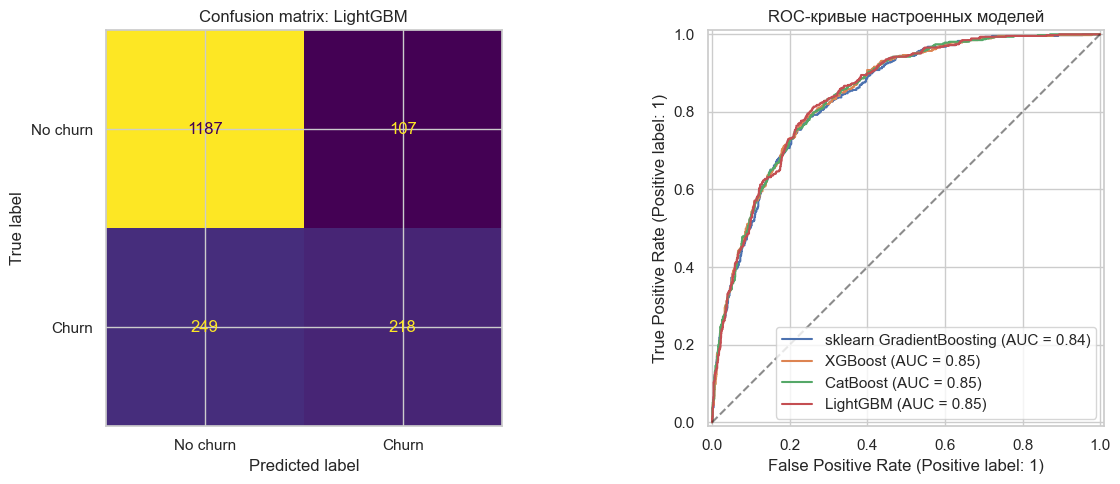

In [23]:
best_name = tuned_results.iloc[0]["model"]
best_model = tuned_models[best_name]
best_predictions = best_model.predict(X_test)

print(f"Итоговый победитель: {best_name}")
print(classification_report(y_test, best_predictions, target_names=["No churn", "Churn"]))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    best_predictions,
    display_labels=["No churn", "Churn"],
    ax=axes[0],
    colorbar=False,
)
axes[0].set_title(f"Confusion matrix: {best_name}")

for name, model in tuned_models.items():
    RocCurveDisplay.from_estimator(model, X_test, y_test, name=name, ax=axes[1])
axes[1].plot([0, 1], [0, 1], "k--", alpha=0.5)
axes[1].set_title("ROC-кривые настроенных моделей")

plt.tight_layout()
plt.show()

## 7. Итоговые ответы на все вопросы задания

In [24]:
baseline_name = baseline_results.iloc[0]["model"]
baseline_auc = baseline_results.iloc[0]["test_roc_auc"]
final_name = tuned_results.iloc[0]["model"]
final_auc = tuned_results.iloc[0]["test_roc_auc"]
final_accuracy = tuned_results.iloc[0]["test_accuracy"]

display(Markdown(f"""
1. **Какой датасет выбран и что показал EDA?**  
   Использован Telco Customer Churn: 7043 клиента, целевая переменная — факт оттока. Доля Churn — {y.mean():.2%}. Более высокий риск связан с небольшим стажем, помесячным контрактом, высокой месячной платой и отсутствием части дополнительных сервисов.

2. **Как выполнены preprocessing и feature engineering?**  
   `customerID` удалён, `TotalCharges` преобразован в число и заполнен медианой обучающей выборки, категориальные признаки закодированы `LabelEncoder`. Добавлены средний платёж на месяц стажа, признак нового клиента и число онлайн-сервисов. Все обучаемые преобразования находятся внутри `Pipeline`, поэтому test и validation не участвуют в их обучении.

3. **Кто лидирует среди моделей из коробки?**  
   **{baseline_name}**, test ROC-AUC = **{baseline_auc:.4f}**. В baseline участвовали ровно четыре обязательные реализации с алгоритмическими параметрами по умолчанию.

4. **Как выполнена настройка?**  
   Для каждой из четырёх моделей основные гиперпараметры подобраны на стратифицированной 3-fold кросс-валидации по ROC-AUC. Тестовая выборка при подборе параметров не использовалась.

5. **Кто победил после настройки?**  
   **{final_name}**, test ROC-AUC = **{final_auc:.4f}**, accuracy = **{final_accuracy:.4f}**. Таблица выше содержит лучшие параметры и изменение ROC-AUC относительно baseline для каждой модели.

6. **Практическая интерпретация.**  
   Модель ранжирует клиентов по вероятности оттока. Полученный скоринг можно использовать для приоритизации retention-кампаний, начиная с клиентов с наибольшим прогнозным риском. Порог классификации следует выбирать отдельно с учётом стоимости контакта и потери клиента; ROC-AUC оценивает качество ранжирования и не задаёт бизнес-порог автоматически.
"""))


1. **Какой датасет выбран и что показал EDA?**  
   Использован Telco Customer Churn: 7043 клиента, целевая переменная — факт оттока. Доля Churn — 26.54%. Более высокий риск связан с небольшим стажем, помесячным контрактом, высокой месячной платой и отсутствием части дополнительных сервисов.

2. **Как выполнены preprocessing и feature engineering?**  
   `customerID` удалён, `TotalCharges` преобразован в число и заполнен медианой обучающей выборки, категориальные признаки закодированы `LabelEncoder`. Добавлены средний платёж на месяц стажа, признак нового клиента и число онлайн-сервисов. Все обучаемые преобразования находятся внутри `Pipeline`, поэтому test и validation не участвуют в их обучении.

3. **Кто лидирует среди моделей из коробки?**  
   **sklearn GradientBoosting**, test ROC-AUC = **0.8451**. В baseline участвовали ровно четыре обязательные реализации с алгоритмическими параметрами по умолчанию.

4. **Как выполнена настройка?**  
   Для каждой из четырёх моделей основные гиперпараметры подобраны на стратифицированной 3-fold кросс-валидации по ROC-AUC. Тестовая выборка при подборе параметров не использовалась.

5. **Кто победил после настройки?**  
   **LightGBM**, test ROC-AUC = **0.8485**, accuracy = **0.7978**. Таблица выше содержит лучшие параметры и изменение ROC-AUC относительно baseline для каждой модели.

6. **Практическая интерпретация.**  
   Модель ранжирует клиентов по вероятности оттока. Полученный скоринг можно использовать для приоритизации retention-кампаний, начиная с клиентов с наибольшим прогнозным риском. Порог классификации следует выбирать отдельно с учётом стоимости контакта и потери клиента; ROC-AUC оценивает качество ранжирования и не задаёт бизнес-порог автоматически.
